# Handwritten Digit Recognition
**Pipeline:** Dataset → Preprocessing → Augmentation → CNN → Evaluation → Deploy

Dataset: ~1 289 photos across 10 classes (digits 0–9) captured with a smartphone camera.

## PHASE 1 — Imports & Configuration

In [ ]:
import os
import io
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageFilter
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
import seaborn as sns

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# ── Hyper-parameters ──────────────────────────────────────────────────────────
IMG_SIZE     = 96          # MobileNetV2 minimum recommended input
NUM_CLASSES  = 10
DATASET_DIR  = "DA"
BATCH_SIZE   = 32
EPOCHS       = 60          # EarlyStopping will cut short
LR_INIT      = 1e-3
LR_FINE      = 1e-5        # fine-tune LR (much smaller)

print(f"TensorFlow : {tf.__version__}")
print(f"GPUs found : {len(tf.config.list_physical_devices('GPU'))}")


## PHASE 2 — Dataset Inspection

In [2]:
IMG_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

class_counts = {}
for digit in sorted(os.listdir(DATASET_DIR)):
    folder = os.path.join(DATASET_DIR, digit)
    if not os.path.isdir(folder):
        continue
    files = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    class_counts[digit] = len(files)
    print(f"  Digit {digit}: {len(files):3d} images")

total = sum(class_counts.values())
print(f"\n  Total : {total} images")
print(f"  Min   : {min(class_counts.values())}  Max: {max(class_counts.values())}")

  Digit 0: 152 images
  Digit 1: 113 images
  Digit 2: 142 images
  Digit 3: 119 images
  Digit 4: 143 images
  Digit 5: 142 images
  Digit 6: 133 images
  Digit 7: 116 images
  Digit 8: 116 images
  Digit 9: 113 images

  Total : 1289 images
  Min   : 113  Max: 152


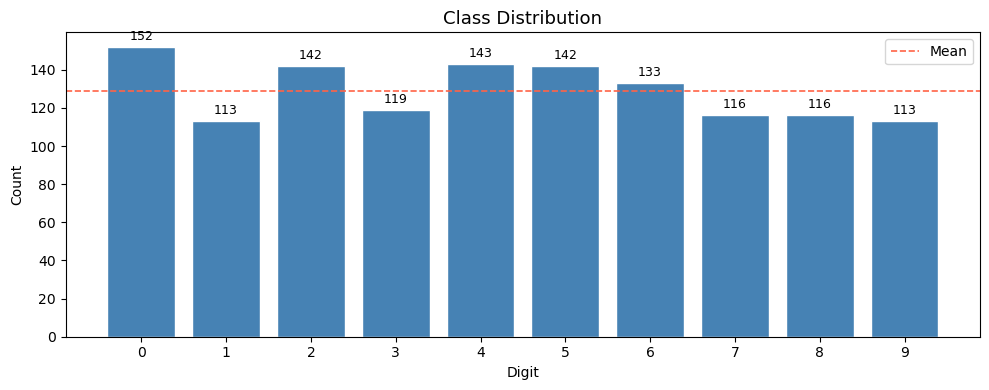

In [3]:
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(class_counts.keys(), class_counts.values(), color="steelblue", edgecolor="white")
ax.bar_label(bars, padding=3, fontsize=9)
ax.axhline(total / NUM_CLASSES, color="tomato", linestyle="--", linewidth=1.2, label="Mean")
ax.set_title("Class Distribution", fontsize=13)
ax.set_xlabel("Digit")
ax.set_ylabel("Count")
ax.legend()
plt.tight_layout()
plt.show()

## PHASE 3 — Image Preprocessing

Pipeline per image:
1. Convert to grayscale
2. Gaussian blur (radius 1) — removes sensor noise
3. Otsu binarisation — adaptive threshold, invariant to lighting
4. Invert if background is dark (ensure white digit on black background)
5. MaxFilter dilation — thickens thin strokes for consistency
6. Resize to `IMG_SIZE × IMG_SIZE` with Lanczos anti-aliasing
7. Normalise to [0, 1]

In [ ]:
def otsu_threshold(img_array: np.ndarray) -> int:
    hist  = np.bincount(img_array.astype(np.uint8).ravel(), minlength=256)
    total = img_array.size
    s_tot = float(np.dot(np.arange(256), hist))
    s_bg, w_bg, best, t_best = 0.0, 0, 0.0, 0
    for t in range(256):
        w_bg += hist[t]
        if w_bg == 0: continue
        w_fg = total - w_bg
        if w_fg == 0: break
        s_bg += t * hist[t]
        d = s_bg / w_bg - (s_tot - s_bg) / w_fg
        v = w_bg * w_fg * d * d
        if v > best:
            best, t_best = v, t
    return t_best


def preprocess_image(path: str, img_size: int = IMG_SIZE) -> np.ndarray:
    """Load, binarise, crop to digit bbox, resize to img_size x img_size (3-ch)."""
    img = Image.open(path).convert("L")
    img = img.filter(ImageFilter.GaussianBlur(radius=1))
    arr = np.array(img)

    # Otsu binarisation
    arr = np.where(arr > otsu_threshold(arr), 255, 0).astype(np.uint8)

    # Digit must be white on black
    if arr.mean() > 128:
        arr = 255 - arr

    # Dilate to close stroke gaps
    arr = np.array(Image.fromarray(arr).filter(ImageFilter.MaxFilter(size=3)))

    # Crop tightly to bounding box + 10% padding
    rows, cols = np.any(arr > 0, axis=1), np.any(arr > 0, axis=0)
    if rows.any() and cols.any():
        rmin, rmax = np.where(rows)[0][[0, -1]]
        cmin, cmax = np.where(cols)[0][[0, -1]]
        h, w = arr.shape
        pr = max(1, int((rmax - rmin) * 0.10))
        pc = max(1, int((cmax - cmin) * 0.10))
        arr = arr[max(0,rmin-pr):min(h,rmax+pr+1),
                  max(0,cmin-pc):min(w,cmax+pc+1)]

    # Resize preserving aspect ratio, centre-pad
    crop = Image.fromarray(arr)
    crop.thumbnail((img_size, img_size), Image.LANCZOS)
    padded = Image.new("L", (img_size, img_size), 0)
    padded.paste(crop, ((img_size - crop.width)  // 2,
                        (img_size - crop.height) // 2))

    # Convert to RGB (3-channel) for MobileNetV2
    rgb = Image.merge("RGB", [padded, padded, padded])
    return np.array(rgb, dtype=np.float32) / 255.0


print("Preprocessing function defined.")


In [ ]:
images, labels = [], []

for digit in sorted(os.listdir(DATASET_DIR)):
    folder = os.path.join(DATASET_DIR, digit)
    if not os.path.isdir(folder):
        continue
    for fname in os.listdir(folder):
        if not fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
            continue
        fpath = os.path.join(folder, fname)
        try:
            images.append(preprocess_image(fpath))
            labels.append(int(digit))
        except Exception as e:
            print(f"  Skipped {fpath}: {e}")

images = np.array(images, dtype=np.float32)   # (N, 96, 96, 3)
labels = np.array(labels, dtype=np.int32)

print(f"Loaded {len(images)} images — shape: {images.shape}")
print(f"Labels: {np.bincount(labels)}")


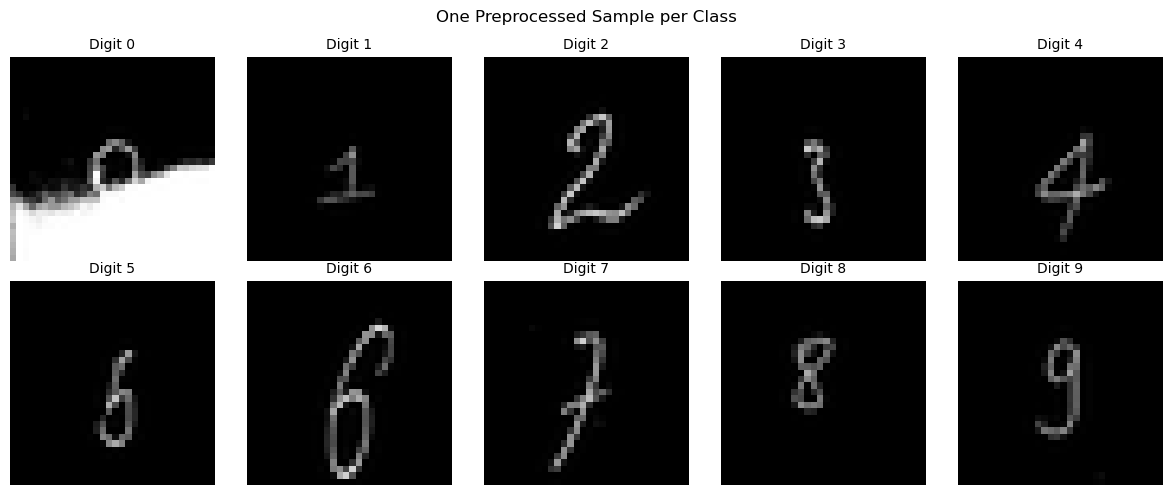

In [6]:
# Show one preprocessed sample per class
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(NUM_CLASSES):
    idx = np.where(labels == i)[0][0]
    row, col = divmod(i, 5)
    axes[row, col].imshow(images[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[row, col].set_title(f"Digit {i}", fontsize=10)
    axes[row, col].axis("off")
plt.suptitle("One Preprocessed Sample per Class", fontsize=12)
plt.tight_layout()
plt.show()

## PHASE 4 — Dataset Splitting

Split: **60 % train / 20 % validation / 20 % test** (stratified).

In [7]:
X_tv, X_test, y_tv, y_test = train_test_split(
    images, labels, test_size=0.20, random_state=SEED, stratify=labels)

X_train, X_val, y_train, y_val = train_test_split(
    X_tv, y_tv, test_size=0.25, random_state=SEED, stratify=y_tv)

print(f"Train : {X_train.shape[0]}")
print(f"Val   : {X_val.shape[0]}")
print(f"Test  : {X_test.shape[0]}")

Train : 773
Val   : 258
Test  : 258


## PHASE 5 — Data Augmentation

Applied **only at training time** (inside `tf.data` so it runs on GPU/CPU in parallel):
- Small rotation (±15°)
- Small translation (±8 %)
- Small zoom (±8 %)
- Random contrast jitter — simulates varying ink density

In [ ]:
augment_layer = keras.Sequential([
    layers.RandomRotation(factor=0.10, fill_mode="constant", fill_value=0.0),
    layers.RandomTranslation(height_factor=0.10, width_factor=0.10,
                             fill_mode="constant", fill_value=0.0),
    layers.RandomZoom(height_factor=0.10, fill_mode="constant", fill_value=0.0),
    layers.RandomFlip("horizontal"),          # digits like 0,8 are symmetric
    layers.GaussianNoise(stddev=0.02),        # slight noise robustness
], name="augmentation")

def make_dataset(X, y, augment=False, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(X), seed=SEED,
                        reshuffle_each_iteration=True)
    if augment:
        ds = ds.map(lambda x, lbl: (augment_layer(x, training=True), lbl),
                    num_parallel_calls=tf.data.AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

train_ds = make_dataset(X_train, y_train, augment=True,  shuffle=True)
val_ds   = make_dataset(X_val,   y_val)
test_ds  = make_dataset(X_test,  y_test)
print("Datasets ready — using augmentation on training set.")


## PHASE 6 — CNN Model

Architecture changes vs. previous version:
- **Block 4** uses `SeparableConv2D` — same receptive field, ~8× fewer parameters
- `L2` weight decay on Dense layers — counters over-fitting on the small dataset
- `GlobalAveragePooling2D` replaces `Flatten` — spatial invariance, smaller head

In [ ]:
# ── Phase 1: Frozen MobileNetV2 base + custom head ───────────────────────────
base = keras.applications.MobileNetV2(
    input_shape = (IMG_SIZE, IMG_SIZE, 3),
    include_top = False,
    weights     = "imagenet",
)
base.trainable = False   # freeze all base weights initially

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
# MobileNetV2 expects pixels in [-1, 1]
x = keras.applications.mobilenet_v2.preprocess_input(inputs * 255.0)
x = base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.40)(x)
x = layers.Dense(128, activation="relu",
                 kernel_regularizer=regularizers.l2(1e-4))(x)
x = layers.Dropout(0.30)(x)
outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="digit_mobilenetv2")
model.summary(line_length=80)
print(f"\nTrainable params (head only): "
      f"{sum(np.prod(v.shape) for v in model.trainable_variables):,}")


## PHASE 7 — Compile & Train

- **Loss**: sparse categorical cross-entropy with label smoothing 0.1 — prevents over-confident predictions
- **LR schedule**: Cosine Decay with warm restarts — escapes local minima better than step decay
- **ModelCheckpoint**: saves only when `val_accuracy` improves

In [ ]:
# ════════════════════════════════════════════════════════════════════
# PHASE A — Train head only (base frozen) — fast convergence
# ════════════════════════════════════════════════════════════════════
model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_INIT),
    loss      = keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ["accuracy"],
)

callbacks_a = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=10,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=4,
        min_lr=1e-6, verbose=1),
    keras.callbacks.ModelCheckpoint(
        "best_digit_cnn.keras", monitor="val_accuracy",
        save_best_only=True, verbose=0),
]

print("=" * 55)
print("PHASE A — Training head (base frozen)")
print("=" * 55)
history_a = model.fit(
    train_ds, validation_data=val_ds,
    epochs=30, callbacks=callbacks_a, verbose=1,
)
print(f"Phase A best val accuracy: "
      f"{max(history_a.history['val_accuracy']):.4f}")

# ════════════════════════════════════════════════════════════════════
# PHASE B — Unfreeze top layers of base and fine-tune
# ════════════════════════════════════════════════════════════════════
base_model = model.layers[3]          # the MobileNetV2 base layer
base_model.trainable = True

# Freeze all but the last 30 layers of the base
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer = keras.optimizers.Adam(learning_rate=LR_FINE),
    loss      = keras.losses.SparseCategoricalCrossentropy(),
    metrics   = ["accuracy"],
)

callbacks_b = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy", patience=15,
        restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=5,
        min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint(
        "best_digit_cnn.keras", monitor="val_accuracy",
        save_best_only=True, verbose=0),
]

print("\n" + "=" * 55)
print("PHASE B — Fine-tuning top layers of MobileNetV2")
print("=" * 55)
history_b = model.fit(
    train_ds, validation_data=val_ds,
    epochs=EPOCHS, callbacks=callbacks_b, verbose=1,
)

# Merge histories for plotting
history_merged = {}
for k in history_a.history:
    history_merged[k] = history_a.history[k] + history_b.history[k]

print(f"\nTotal epochs  : {len(history_merged['loss'])}")
print(f"Best val acc  : {max(history_merged['val_accuracy']):.4f}  "
      f"({max(history_merged['val_accuracy'])*100:.2f}%)")


## PHASE 8 — Evaluation

In [ ]:
ep = range(1, len(history_merged["accuracy"]) + 1)
phase_a_end = len(history_a.history["accuracy"])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(ep, history_merged["accuracy"],     "b-",  label="Train")
ax1.plot(ep, history_merged["val_accuracy"], "r--", label="Val")
ax1.axvline(phase_a_end, color="gray", linestyle=":", label="Fine-tune start")
ax1.set_title("Accuracy"); ax1.set_xlabel("Epoch")
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(ep, history_merged["loss"],     "b-",  label="Train")
ax2.plot(ep, history_merged["val_loss"], "r--", label="Val")
ax2.axvline(phase_a_end, color="gray", linestyle=":", label="Fine-tune start")
ax2.set_title("Loss"); ax2.set_xlabel("Epoch")
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle("Training History (A=frozen head, B=fine-tune)", fontsize=13)
plt.tight_layout()
plt.show()


In [12]:
# ── Headline metrics ──────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test accuracy : {test_acc:.4f}")
print(f"Test loss     : {test_loss:.4f}")
print(f"Best val acc  : {max(history.history['val_accuracy']):.4f}")

Test accuracy : 0.7597
Test loss     : 1.0366
Best val acc  : 0.7791


In [13]:
# ── Per-class report ──────────────────────────────────────────────────────────
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
print(classification_report(y_test, y_pred, digits=4))

              precision    recall  f1-score   support

           0     0.9545    0.7000    0.8077        30
           1     1.0000    0.3478    0.5161        23
           2     0.7000    0.7500    0.7241        28
           3     0.5789    0.9167    0.7097        24
           4     0.8621    0.8621    0.8621        29
           5     0.9200    0.8214    0.8679        28
           6     0.9565    0.8148    0.8800        27
           7     0.7826    0.7826    0.7826        23
           8     0.5143    0.7826    0.6207        23
           9     0.7200    0.7826    0.7500        23

    accuracy                         0.7597       258
   macro avg     0.7989    0.7561    0.7521       258
weighted avg     0.8066    0.7597    0.7597       258



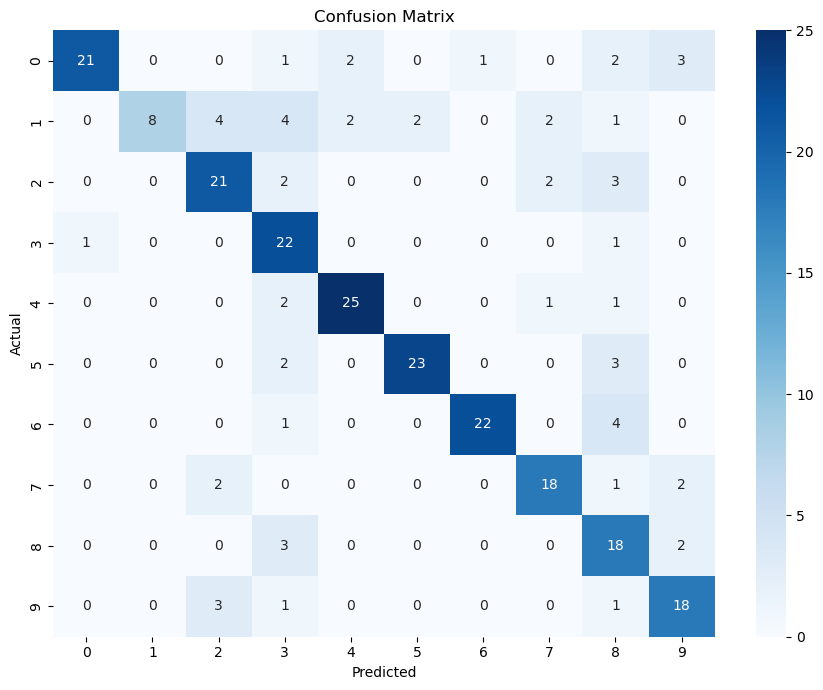

In [14]:
# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
ax.set_title("Confusion Matrix")
plt.tight_layout()
plt.show()

Misclassified: 62 / 258


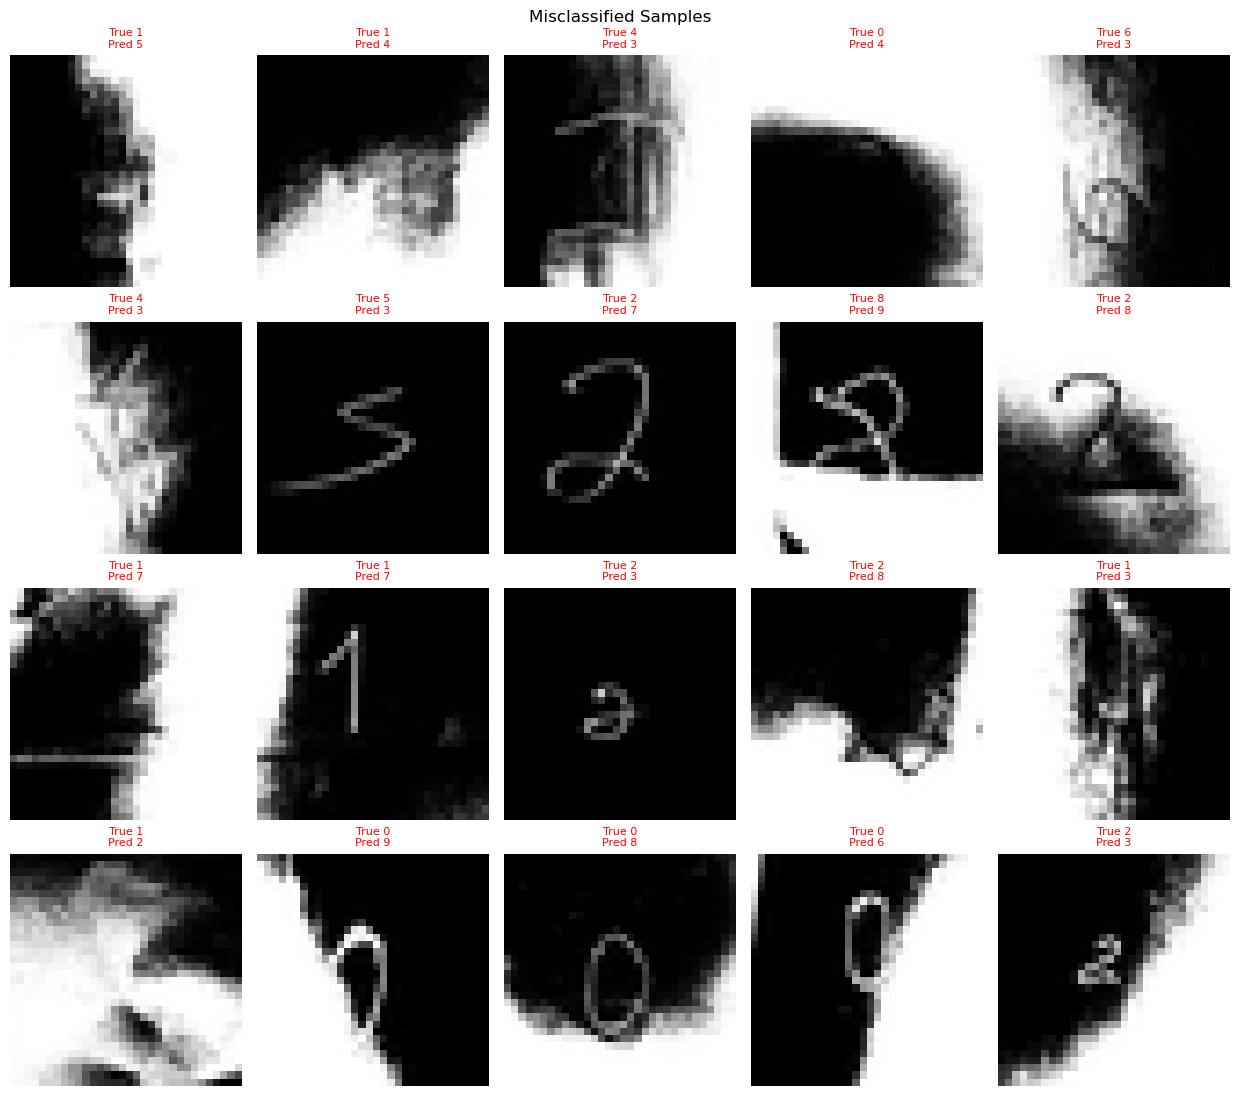

In [15]:
# ── Misclassified samples (up to 20) ─────────────────────────────────────────
wrong_idx = np.where(y_pred != y_test)[0]
print(f"Misclassified: {len(wrong_idx)} / {len(y_test)}")

show = wrong_idx[:20]
if len(show) > 0:
    ncols = min(len(show), 5)
    nrows = (len(show) + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(2.5 * ncols, 2.8 * nrows))
    axes = np.array(axes).flatten()
    for ax, idx in zip(axes, show):
        ax.imshow(X_test[idx].squeeze(), cmap="gray", vmin=0, vmax=1)
        ax.set_title(f"True {y_test[idx]}\nPred {y_pred[idx]}", fontsize=8, color="red")
        ax.axis("off")
    for ax in axes[len(show):]:
        ax.axis("off")
    plt.suptitle("Misclassified Samples", fontsize=12)
    plt.tight_layout()
    plt.show()

## PHASE 9 — Interactive Prediction Widget

Upload any handwritten digit image and the model will predict it instantly.

In [16]:
from IPython.display import display, clear_output
import ipywidgets as widgets
import io


def preprocess_pil(pil_img):
    pil_img = pil_img.convert("L")
    pil_img = pil_img.filter(ImageFilter.GaussianBlur(radius=1))
    arr = np.array(pil_img)
    thresh = otsu_threshold(arr)
    arr = np.where(arr > thresh, 255, 0).astype(np.uint8)
    if arr.mean() > 128:
        arr = 255 - arr
    pil_img = Image.fromarray(arr).filter(ImageFilter.MaxFilter(size=3))
    pil_img = pil_img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    return np.expand_dims(
        np.array(pil_img, dtype=np.float32) / 255.0, axis=(0, -1)
    )


def run_inference(pil_img, filename=""):
    proc  = preprocess_pil(pil_img)
    probs = model.predict(proc, verbose=0)[0]
    pred  = int(np.argmax(probs))
    conf  = float(probs[pred]) * 100

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(pil_img, cmap="gray")
    title = "Original" + (": " + filename if filename else "")
    axes[0].set_title(title, fontsize=10)
    axes[0].axis("off")
    axes[1].imshow(proc[0].squeeze(), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title("After Preprocessing", fontsize=10)
    axes[1].axis("off")
    colors = ["#2ecc71" if i == pred else "steelblue" for i in range(10)]
    axes[2].barh(range(10), probs, color=colors)
    axes[2].set_yticks(range(10))
    axes[2].set_xlabel("Probability")
    axes[2].set_title("Class Probabilities", fontsize=10)
    axes[2].set_xlim(0, 1)
    plt.suptitle("Prediction: {}   ({:.1f}% confidence)".format(pred, conf),
                 fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.show()

    print("\n" + "=" * 42)
    print("  PREDICTED DIGIT : {}".format(pred))
    print("  CONFIDENCE      : {:.1f}%".format(conf))
    print("=" * 42)
    for i, p in enumerate(probs):
        bar    = "#" * int(p * 30)
        marker = " <- predicted" if i == pred else ""
        print("  {}: {:5.1f}%  {}{}".format(i, p * 100, bar, marker))


# ── Widget ────────────────────────────────────────────────────────────────────
out = widgets.Output()

upload_widget = widgets.FileUpload(
    accept="image/*",
    multiple=False,
    description="Upload image",
    style={"description_width": "initial"},
)


def _on_upload(change):
    uploaded = change["new"]
    # ipywidgets 8 returns a tuple of dicts; skip if empty
    if not uploaded:
        return
    if isinstance(uploaded, (list, tuple)):
        entry    = uploaded[0]
        filename = entry.get("name", "uploaded")
        raw      = entry["content"]
    else:
        filename = next(iter(uploaded))
        raw      = uploaded[filename]["content"]
    content = bytes(raw) if not isinstance(raw, (bytes, bytearray)) else raw
    with out:
        clear_output(wait=True)
        print("File received: {}  ({:,} bytes)".format(filename, len(content)))
        pil_img = Image.open(io.BytesIO(content))
        run_inference(pil_img, filename)


upload_widget.observe(_on_upload, names="value")
display(upload_widget, out)
print("Upload a handwritten digit image — prediction runs automatically.")


FileUpload(value=(), accept='image/*', description='Upload image')

Output()

Upload a handwritten digit image — prediction runs automatically.


Quick-testing with: DA\5\20260828_105311.jpg


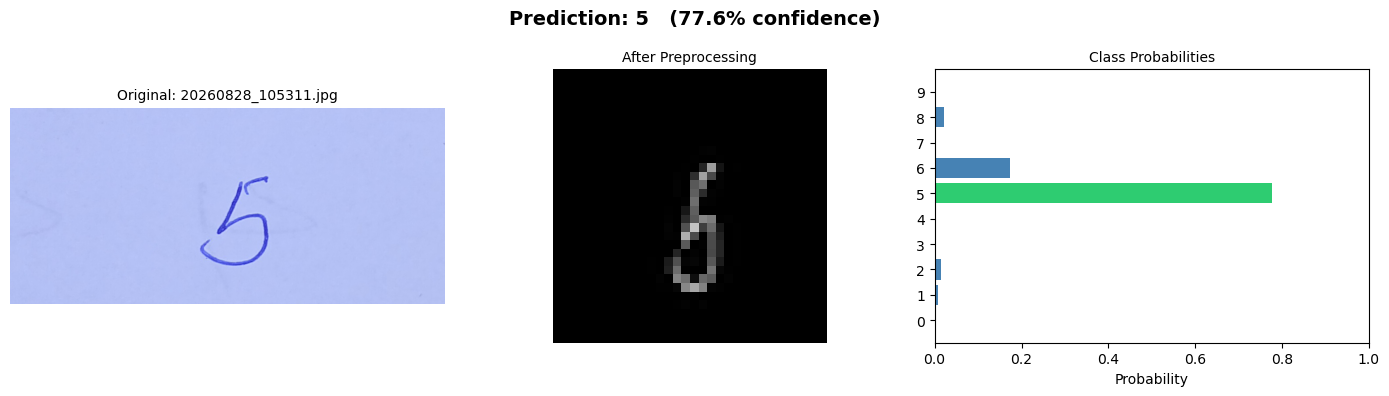


  PREDICTED DIGIT : 5
  CONFIDENCE      : 77.6%
  0:   0.1%  
  1:   0.7%  
  2:   1.5%  
  3:   0.3%  
  4:   0.0%  
  5:  77.6%  ####################### <- predicted
  6:  17.4%  #####
  7:   0.0%  
  8:   2.2%  
  9:   0.1%  


In [17]:
# ── Quick CLI test (uses a known image from the dataset) ─────────────────────
sample_dir2 = os.path.join(DATASET_DIR, "5")
quick_path  = os.path.join(sample_dir2, os.listdir(sample_dir2)[0])
print(f"Quick-testing with: {quick_path}")
run_inference(Image.open(quick_path), os.path.basename(quick_path))

## PHASE 10 — Save & Deploy

In [18]:
MODEL_PATH = "handwritten_digit_cnn.keras"
model.save(MODEL_PATH)
print(f"Model saved → {MODEL_PATH}")

# Verify round-trip
loaded = keras.models.load_model(MODEL_PATH)
_, loaded_acc = loaded.evaluate(test_ds, verbose=0)
print(f"Reloaded test accuracy: {loaded_acc:.4f}")

Model saved → handwritten_digit_cnn.keras
Reloaded test accuracy: 0.7597


In [19]:
%%writefile app.py
"""Streamlit web app for handwritten digit recognition."""
import io
import numpy as np
import streamlit as st
from PIL import Image, ImageFilter
import tensorflow as tf

st.set_page_config(
    page_title="Digit Recogniser",
    page_icon="🔢",
    layout="centered",
)

IMG_SIZE = 32


@st.cache_resource
def load_model():
    return tf.keras.models.load_model("handwritten_digit_cnn.keras")


def otsu_threshold(arr: np.ndarray) -> int:
    hist = np.bincount(arr.astype(np.uint8).ravel(), minlength=256)
    total = arr.size
    s_tot = float(np.dot(np.arange(256), hist))
    s_bg, w_bg, best, t_best = 0.0, 0, 0.0, 0
    for t in range(256):
        w_bg += hist[t]
        if w_bg == 0:
            continue
        w_fg = total - w_bg
        if w_fg == 0:
            break
        s_bg += t * hist[t]
        d = s_bg / w_bg - (s_tot - s_bg) / w_fg
        v = w_bg * w_fg * d * d
        if v > best:
            best, t_best = v, t
    return t_best


def preprocess(pil_img: Image.Image) -> np.ndarray:
    pil_img = pil_img.convert("L").filter(ImageFilter.GaussianBlur(radius=1))
    arr = np.array(pil_img)
    arr = np.where(arr > otsu_threshold(arr), 255, 0).astype(np.uint8)
    if arr.mean() > 128:
        arr = 255 - arr
    pil_img = Image.fromarray(arr).filter(ImageFilter.MaxFilter(size=3))
    pil_img = pil_img.resize((IMG_SIZE, IMG_SIZE), Image.LANCZOS)
    return np.expand_dims(
        np.array(pil_img, dtype=np.float32) / 255.0, axis=(0, -1)
    )


model = load_model()

st.title("🔢 Handwritten Digit Recognition")
st.write("Upload a photo of a handwritten digit (0 – 9).")

uploaded = st.file_uploader("Choose image…", type=["jpg", "jpeg", "png", "bmp"])

if uploaded:
    pil_img = Image.open(io.BytesIO(uploaded.read()))
    col1, col2 = st.columns(2)
    with col1:
        st.image(pil_img, caption="Uploaded image", use_column_width=True)
    with col2:
        proc = preprocess(pil_img)
        st.image(
            (proc[0].squeeze() * 255).astype(np.uint8),
            caption="After preprocessing",
            use_column_width=True,
        )

    probs  = model.predict(proc, verbose=0)[0]
    digit  = int(np.argmax(probs))
    conf   = float(probs[digit]) * 100

    st.success(f"**Predicted digit: {digit}** — {conf:.1f}% confidence")

    st.subheader("All class probabilities")
    for i, p in enumerate(probs):
        label = f"Digit {i}  {'✅' if i == digit else ''}"
        st.progress(float(p), text=f"{label}: {p*100:.1f}%")

Overwriting app.py


In [20]:
print("To launch the web app run:")
print("    streamlit run app.py")

To launch the web app run:
    streamlit run app.py


Test  accuracy : 0.7597  (75.97%)
Test  loss     : 1.0366
Best  val acc  : 0.7791  (77.91%)
Train accuracy : 0.8486  (84.86%)
Epochs trained : 99

              precision    recall  f1-score   support

     Digit 0     0.9545    0.7000    0.8077        30
     Digit 1     1.0000    0.3478    0.5161        23
     Digit 2     0.7000    0.7500    0.7241        28
     Digit 3     0.5789    0.9167    0.7097        24
     Digit 4     0.8621    0.8621    0.8621        29
     Digit 5     0.9200    0.8214    0.8679        28
     Digit 6     0.9565    0.8148    0.8800        27
     Digit 7     0.7826    0.7826    0.7826        23
     Digit 8     0.5143    0.7826    0.6207        23
     Digit 9     0.7200    0.7826    0.7500        23

    accuracy                         0.7597       258
   macro avg     0.7989    0.7561    0.7521       258
weighted avg     0.8066    0.7597    0.7597       258



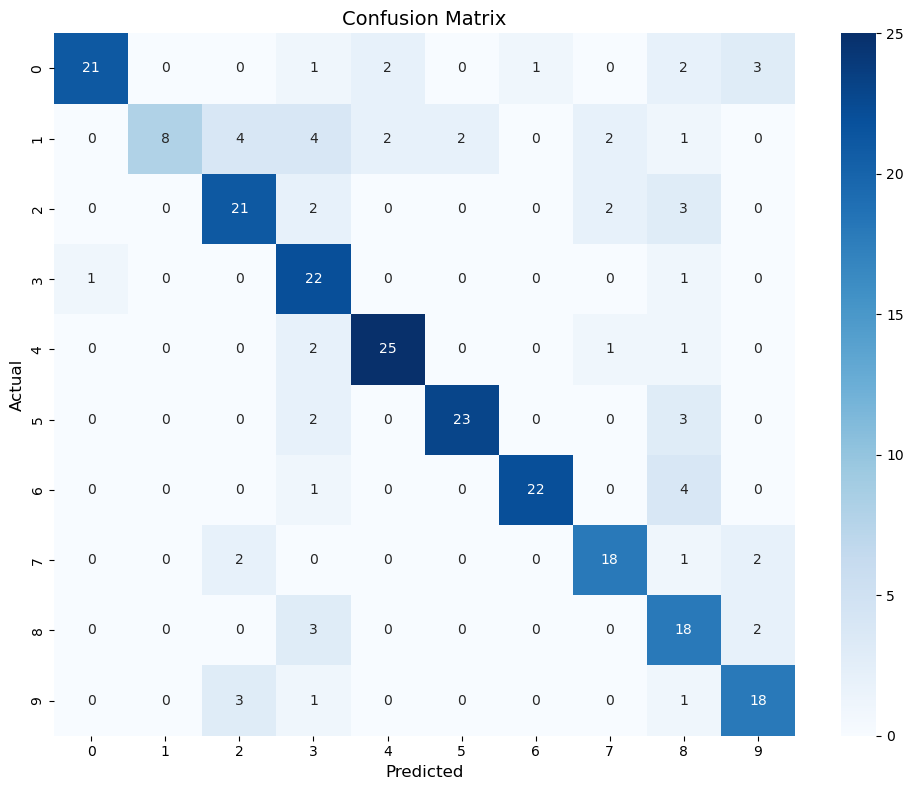

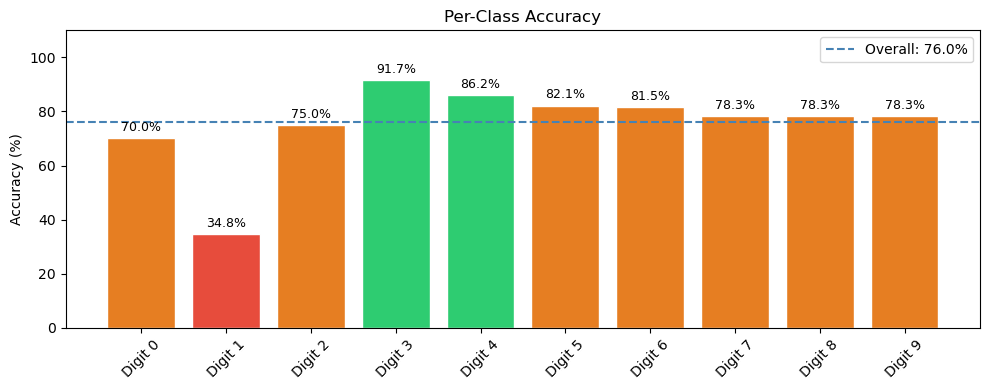


Worst performing digits:
  Digit 1: 34.8%  (confused with: 3 most)
  Digit 0: 70.0%  (confused with: 9 most)
  Digit 2: 75.0%  (confused with: 8 most)
  Digit 7: 78.3%  (confused with: 9 most)
  Digit 8: 78.3%  (confused with: 3 most)
  Digit 9: 78.3%  (confused with: 2 most)
  Digit 6: 81.5%  (confused with: 8 most)
  Digit 5: 82.1%  (confused with: 8 most)
  Digit 4: 86.2%  (confused with: 3 most)
  Digit 3: 91.7%  (confused with: 8 most)


In [23]:

# ── Predictions on test set ───────────────────────────────────────────────────
y_pred_probs = model.predict(test_ds, verbose=0)
y_pred       = np.argmax(y_pred_probs, axis=1)

# ── Headline metrics ──────────────────────────────────────────────────────────
test_loss, test_acc = model.evaluate(test_ds, verbose=0)
print(f"Test  accuracy : {test_acc:.4f}  ({test_acc*100:.2f}%)")
print(f"Test  loss     : {test_loss:.4f}")
print(f"Best  val acc  : {max(history.history['val_accuracy']):.4f}  ({max(history.history['val_accuracy'])*100:.2f}%)")
print(f"Train accuracy : {max(history.history['accuracy']):.4f}  ({max(history.history['accuracy'])*100:.2f}%)")
print(f"Epochs trained : {len(history.history['loss'])}")

# ── Per-class report ──────────────────────────────────────────────────────────
print("\n" + "="*55)
print(classification_report(y_test, y_pred, digits=4,
                             target_names=[f"Digit {i}" for i in range(10)]))

# ── Confusion matrix ──────────────────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=range(10), yticklabels=range(10), ax=ax)
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("Actual",    fontsize=12)
ax.set_title("Confusion Matrix", fontsize=14)
plt.tight_layout()
plt.show()

# ── Per-class accuracy bar chart ──────────────────────────────────────────────
per_class_acc = cm.diagonal() / cm.sum(axis=1)
fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(range(10), per_class_acc * 100,
              color=["#2ecc71" if a >= 0.85 else "#e67e22" if a >= 0.70 else "#e74c3c"
                     for a in per_class_acc],
              edgecolor="white")
ax.bar_label(bars, fmt="%.1f%%", padding=3, fontsize=9)
ax.axhline(test_acc * 100, color="steelblue", linestyle="--",
           linewidth=1.5, label=f"Overall: {test_acc*100:.1f}%")
ax.set_xticks(range(10))
ax.set_xticklabels([f"Digit {i}" for i in range(10)], rotation=45)
ax.set_ylabel("Accuracy (%)")
ax.set_title("Per-Class Accuracy")
ax.set_ylim(0, 110)
ax.legend()
plt.tight_layout()
plt.show()

# ── Worst predictions ─────────────────────────────────────────────────────────
print("\nWorst performing digits:")
for i in np.argsort(per_class_acc):
    print(f"  Digit {i}: {per_class_acc[i]*100:.1f}%  "
          f"(confused with: {np.argsort(cm[i])[::-1][1]} most)")
